In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import shap
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')  # or your exact filename

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn Rate:")
print(df['Churn'].value_counts(normalize=True) * 100)


df.info()
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn Rate:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Drop customerID (useless for modeling)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# New engineered features (these add real value)
df['TenureMonths'] = df['tenure']  # already there but clear name
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)  # avoid div by zero
df['TotalServices'] = (df[['PhoneService', 'InternetService', 'OnlineSecurity',
                           'OnlineBackup', 'DeviceProtection', 'TechSupport',
                           'StreamingTV', 'StreamingMovies']] != 'No').sum(axis=1)

df['HasFiber'] = (df['InternetService'] == 'Fiber optic').astype(int)
df['ContractType'] = df['Contract'].map({'Month-to-month': 'Monthly', 'One year': 'Annual', 'Two year': 'Biennial'})

print("New features added. Head of engineered columns:")
print(df[['AvgMonthlyCharge', 'TotalServices', 'HasFiber']].head())

New features added. Head of engineered columns:
   AvgMonthlyCharge  TotalServices  HasFiber
0         29.850000              2         0
1         55.573529              4         0
2         54.075000              4         0
3         40.905556              4         0
4         75.825000              2         1


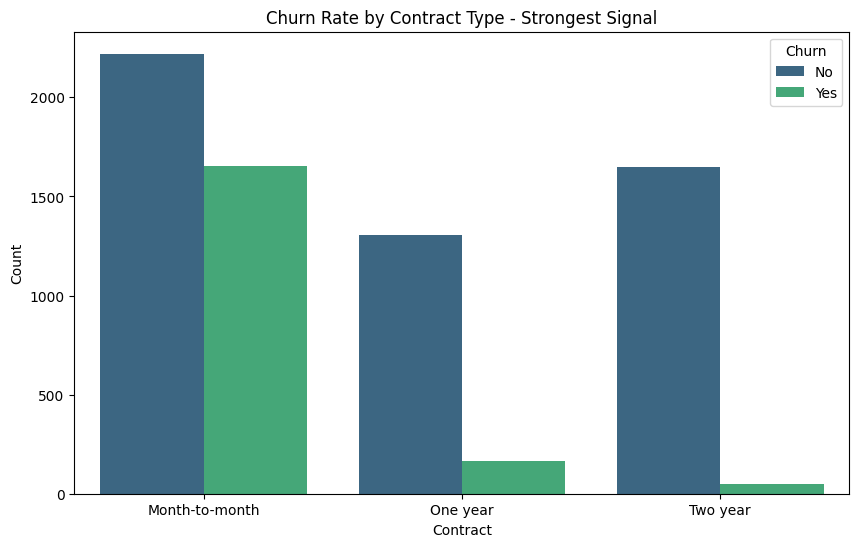

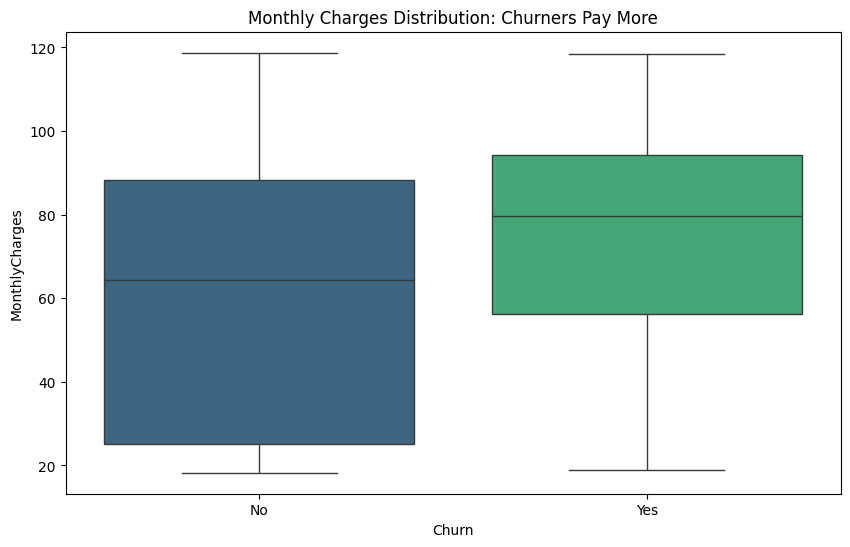

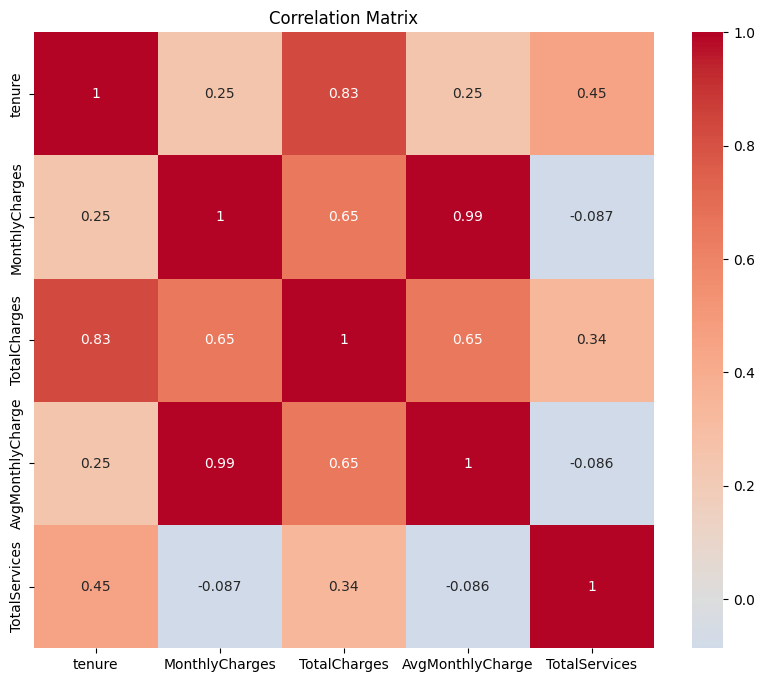


Churn % by InternetService:
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Yes, dtype: float64

Churn % by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Yes, dtype: float64

Churn % by SeniorCitizen:
SeniorCitizen
0    23.606168
1    41.681261
Name: Yes, dtype: float64

Churn % by Partner:
Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

Churn % by Dependents:
Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64


In [3]:
# 1. Churn by Contract Type (classic but powerful)
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Rate by Contract Type - Strongest Signal')
plt.ylabel('Count')
plt.show()

# 2. Monthly Charges Distribution by Churn
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='viridis')
plt.title('Monthly Charges Distribution: Churners Pay More')
plt.show()

# 3. Interactive Plotly version (great for dashboard feel)
fig = px.histogram(df, x='tenure', color='Churn', barmode='group',
                   title='Churn by Tenure (New Customers at Highest Risk)',
                   nbins=30)
fig.show()

# 4. Correlation heatmap (numeric features)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'TotalServices']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# 5. Churn % by Key Categorical Features (stacked bar)
key_cats = ['InternetService', 'PaymentMethod', 'SeniorCitizen', 'Partner', 'Dependents']
for col in key_cats:
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
    print(f"\nChurn % by {col}:\n{churn_rate}")

=== Model Performance ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC: 0.8388992224030587


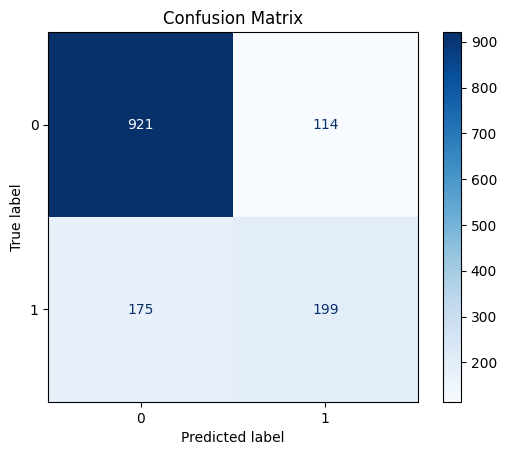

In [4]:
# Define features
target = 'Churn'
X = df.drop(target, axis=1)
y = df[target].map({'Yes': 1, 'No': 0})

# Identify column types
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ])

# Full pipeline with XGBoost (strong performer on this dataset)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='auc', n_estimators=300, learning_rate=0.05))
])

# Train-test split (stratified because of imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit
model.fit(X_train, y_train)

# Predictions & Metrics
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("=== Model Performance ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

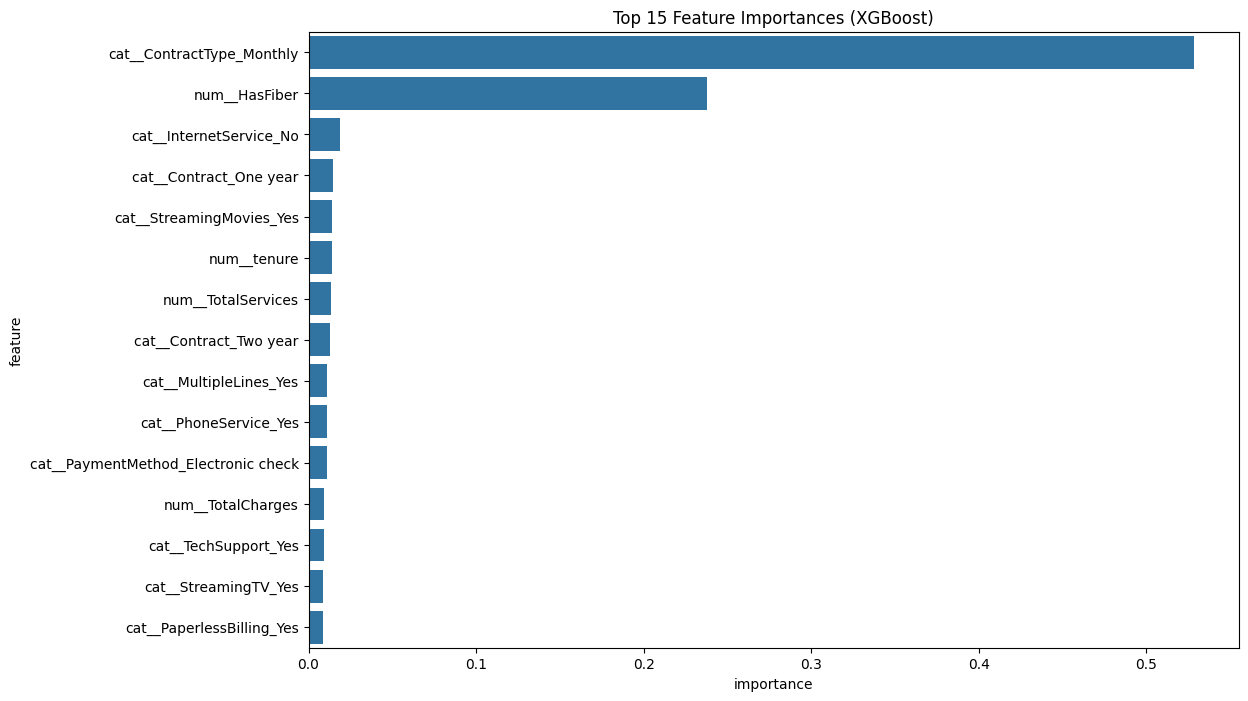

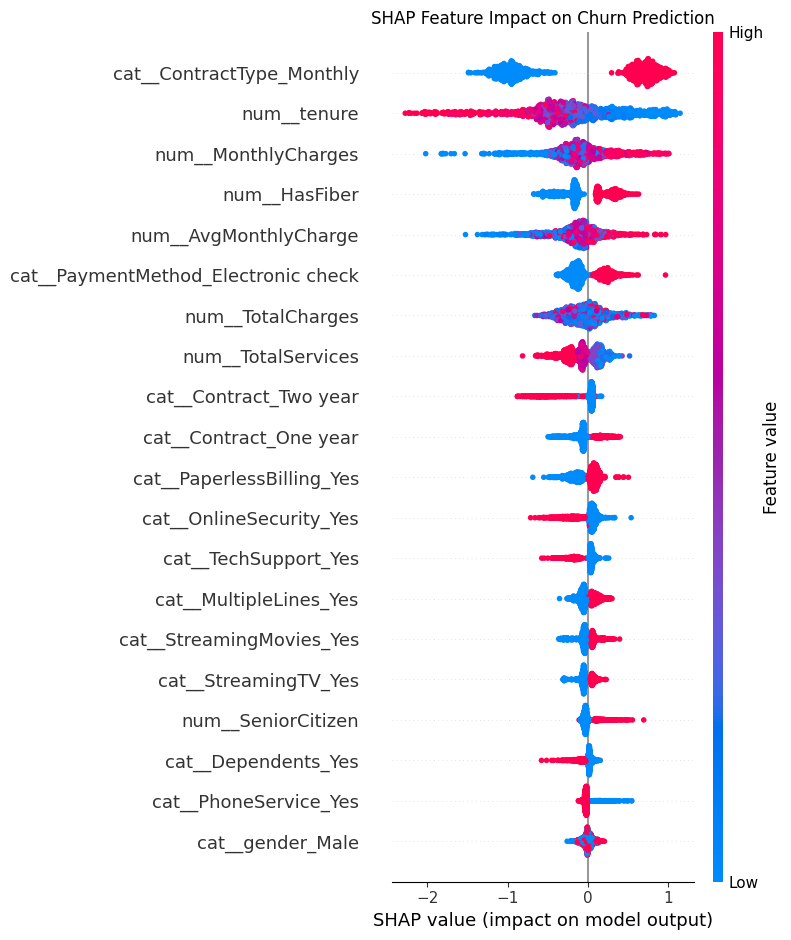

In [5]:
# Feature importance (global)
importances = model.named_steps['classifier'].feature_importances_
feature_names = (model.named_steps['preprocessor']
                 .get_feature_names_out())

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12,8))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

# SHAP for local + global explainability (very 2026)
explainer = shap.TreeExplainer(model.named_steps['classifier'])
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title('SHAP Feature Impact on Churn Prediction')
plt.tight_layout()
plt.show()

In [6]:
# Calculate baseline revenue impact
churn_rate = df['Churn'].value_counts(normalize=True)['Yes']
total_customers = len(df)
churned_customers = int(total_customers * churn_rate)

# Assume average Monthly ARPU (adjust to your context - e.g. 60 MAD ~ $6 USD, or higher for premium segment)
monthly_arpu = 12.0   # USD - conservative for illustration; change to 60 if using MAD and higher-value customers
annual_arpu = monthly_arpu * 12

# Annual revenue leakage from churn (simplified - assumes churned customers would have stayed full year)
annual_revenue_loss = churned_customers * annual_arpu
print(f"Estimated annual revenue loss from churn: ${annual_revenue_loss:,.0f} USD")

# Scenario: Reduce churn by 15% relatively (realistic with targeted interventions)
relative_reduction = 0.15
new_churn_rate = churn_rate * (1 - relative_reduction)
retained_customers = int(churned_customers * relative_reduction)
retained_revenue = retained_customers * annual_arpu

print(f"With 15% relative churn reduction: Retain ~{retained_customers} customers")
print(f"Potential annual revenue saved: ${retained_revenue:,.0f} USD")

Estimated annual revenue loss from churn: $269,136 USD
With 15% relative churn reduction: Retain ~280 customers
Potential annual revenue saved: $40,320 USD


In [7]:
# For Morocco context - example realistic ARPU
monthly_arpu_mad = 80   # ~8.5 USD (reasonable for mixed postpaid/fiber segment)
exchange_rate = 0.107   # 1 MAD ≈ 0.107 USD

monthly_arpu_usd = monthly_arpu_mad * exchange_rate
annual_arpu_usd = monthly_arpu_usd * 12

# Recalculate (replace previous block)
churn_rate = 0.26536987
total_customers = 7043
churned_customers = int(total_customers * churn_rate)

annual_revenue_loss = churned_customers * annual_arpu_usd
relative_reduction = 0.15
retained_customers = int(churned_customers * relative_reduction)
retained_revenue = retained_customers * annual_arpu_usd

print(f"Using MAD {monthly_arpu_mad} monthly ARPU (~${monthly_arpu_usd:.1f} USD)")
print(f"Estimated annual revenue loss: ${annual_revenue_loss:,.0f} USD")
print(f"With 15% relative churn reduction: Retain ~{retained_customers} customers")
print(f"Potential annual revenue saved: ${retained_revenue:,.0f} USD")

Using MAD 80 monthly ARPU (~$8.6 USD)
Estimated annual revenue loss: $191,881 USD
With 15% relative churn reduction: Retain ~280 customers
Potential annual revenue saved: $28,762 USD
